In [1]:
import keras
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# 재현성 고정
keras.utils.set_random_seed(42)

In [2]:
# 데이터 가져오기
(train_input, train_target), (test_input, test_target) = keras.datasets.cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 12s 0us/step


In [3]:
print("train_input :", train_input.shape)
print("train_target:", train_target.shape)

print("test_input  :", test_input.shape)
print("test_target :", test_target.shape)

train_input : (50000, 32, 32, 3)
train_target: (50000, 1)
test_input  : (10000, 32, 32, 3)
test_target : (10000, 1)


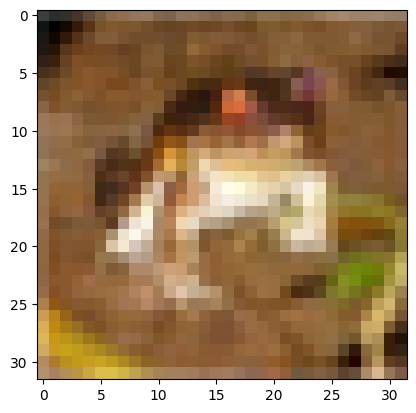

[6]


In [ ]:
# 첫 번째 이미지 확인
plt.imshow(train_input[0])
plt.show()

print(train_target[0])

In [ ]:
# CIFAR-10 레이블 shape 변경
# (50000, 1) -> (50000,)
train_target = train_target.reshape(-1)
test_target = test_target.reshape(-1)

print(train_target.shape)
print(test_target.shape)

(50000,)
(10000,)


In [ ]:
# 픽셀값 정규화
# 0~255 범위를 0~1 범위로 변환
# 신경망 학습 안정화 및 수렴 속도 향상
train_scaled = train_input / 255.0
test_scaled = test_input / 255.0

print(train_scaled.min())
print(train_scaled.max())

0.0
1.0


In [ ]:
# 학습용 데이터와 검증용 데이터 분리
# train : 모델 학습
# validation : 학습 중 성능 확인
train_scaled, val_scaled, train_target, val_target = train_test_split(
    train_scaled, train_target, test_size=0.2, random_state=42
)

In [9]:
# shape 확인
print("train_scaled:", train_scaled.shape)
print("val_scaled  :", val_scaled.shape)
print("train_target:", train_target.shape)
print("val_target  :", val_target.shape)
print("test_scaled :", test_scaled.shape)
print("test_target :", test_target.shape)

train_scaled: (40000, 32, 32, 3)
val_scaled  : (10000, 32, 32, 3)
train_target: (40000,)
val_target  : (10000,)
test_scaled : (10000, 32, 32, 3)
test_target : (10000,)


In [ ]:
# CIFAR-10 Dense 모델 생성
model = keras.Sequential([
    keras.layers.Input(shape=(32, 32, 3)),
    keras.layers.Flatten(),  ## 32×32×3 RGB 이미지를 3072개의 1차원 벡터로 변환
    keras.layers.Dense(100, activation="relu"),
    keras.layers.Dense(10, activation="softmax"),
])

In [25]:
# 모델 컴파일
model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=['accuracy'])

In [26]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 100)            │       307,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 308,310 (1.18 MB)

 Trainable params: 308,310 (1.18 MB)

 Non-trainable params: 0 (0.00 B)

In [27]:
# 학습
history = model.fit(train_scaled, train_target, epochs=10, batch_size=32, validation_data=(val_scaled, val_target))

Epoch 1/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.2957 - loss: 1.9483 - val_accuracy: 0.3130 - val_loss: 1.8738
Epoch 2/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.3533 - loss: 1.8157 - val_accuracy: 0.3554 - val_loss: 1.7869
Epoch 3/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.3698 - loss: 1.7777 - val_accuracy: 0.3691 - val_loss: 1.7641
Epoch 4/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.3791 - loss: 1.7543 - val_accuracy: 0.3790 - val_loss: 1.7380
Epoch 5/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.3854 - loss: 1.7360 - val_accuracy: 0.3815 - val_loss: 1.7252
Epoch 6/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.3908 - loss: 1.7194 - val_accuracy: 0.3850 - val_loss: 1.7208
Epoch 7/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.3945 - loss: 1.7071 - val_accuracy: 0.3841 - val_loss: 1.7165
Epoch 8/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.3995 - loss: 1.6954 - 

In [28]:
# 평가
loss, acc = model.evaluate(test_scaled, test_target, verbose=0)

In [29]:
print("CIFAR-10 Dense Test Accuracy:", acc)
print("마지막 Validation Accuracy:", history.history["val_accuracy"][-1])

CIFAR-10 Dense Test Accuracy: 0.3878999948501587
마지막 Validation Accuracy: 0.3871000111103058


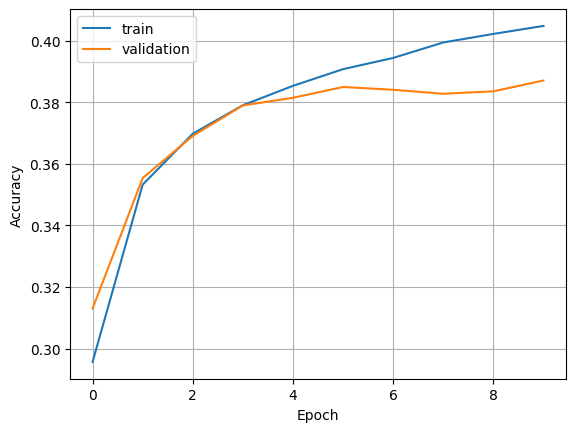

In [30]:
plt.plot(history.history["accuracy"], label="train")
plt.plot(history.history["val_accuracy"], label="validation")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid()

plt.show()

```text
CIFAR-10 데이터셋에 Dense 모델을 적용한 결과
Validation Accuracy는 약 41.9% 수준에 머물렀다.

Fashion-MNIST에서는 약 87%의 정확도를 얻었지만,
CIFAR-10은 컬러 이미지이며 객체의 형태와 위치 정보가 중요하기 때문에
Flatten 후 Dense만 사용하는 구조로는 특징을 충분히 학습하기 어려웠다.

특히 Flatten 과정에서 이미지의 공간 정보가 사라지므로
모서리, 질감, 형태와 같은 패턴을 효과적으로 학습하지 못한다.

따라서 CIFAR-10과 같은 이미지 분류 문제에서는
Dense 신경망보다 CNN(Convolutional Neural Network)이 훨씬 적합함을 확인하였다.
```


---
## Adam Learning Rate 실험

- 0.0001 : 매우 작은 학습률
- 0.001  : Adam 기본값
- 0.01   : 큰 학습률
- 0.1    : 매우 큰 학습률 (발산 가능)

#### learning_rate=0.0001

In [56]:
keras.utils.set_random_seed(42)

In [57]:
model = keras.Sequential(
    [
        keras.layers.Input(shape=(32, 32, 3)),
        keras.layers.Flatten(),
        keras.layers.Dense(100, activation="relu"),
        keras.layers.Dense(10, activation="softmax"),
    ]
)

In [58]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [59]:
history_0001 = model.fit(
    train_scaled,
    train_target,
    epochs=10,
    batch_size=32,
    validation_data=(val_scaled, val_target),
    verbose=0,
)

In [60]:
loss_0001, acc_0001 = model.evaluate(val_scaled, val_target, verbose=0)

print("Adam lr=0.0001:", acc_0001)

Adam lr=0.0001: 0.44909998774528503



---
#### learning_rate=0.001

In [61]:
keras.utils.set_random_seed(42)

In [62]:
model = keras.Sequential(
    [
        keras.layers.Input(shape=(32, 32, 3)),
        keras.layers.Flatten(),
        keras.layers.Dense(100, activation="relu"),
        keras.layers.Dense(10, activation="softmax"),
    ]
)

In [63]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [64]:
history_001 = model.fit(
    train_scaled,
    train_target,
    epochs=10,
    batch_size=32,
    validation_data=(val_scaled, val_target),
    verbose=0,
)

In [65]:
loss_001, acc_001 = model.evaluate(val_scaled, val_target, verbose=0)

print("Adam lr=0.001:", acc_001)

Adam lr=0.001: 0.40849998593330383



---
#### learning_rate=0.01

In [66]:
keras.utils.set_random_seed(42)

In [67]:
model = keras.Sequential(
    [
        keras.layers.Input(shape=(32, 32, 3)),
        keras.layers.Flatten(),
        keras.layers.Dense(100, activation="relu"),
        keras.layers.Dense(10, activation="softmax"),
    ]
)

In [68]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.01),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [69]:
history_01 = model.fit(
    train_scaled,
    train_target,
    epochs=10,
    batch_size=32,
    validation_data=(val_scaled, val_target),
    verbose=0,
)

In [70]:
loss_01, acc_01 = model.evaluate(val_scaled, val_target, verbose=0)

print("Adam lr=0.01:", acc_01)

Adam lr=0.01: 0.18140000104904175




---
#### learning_rate=0.1

In [71]:
keras.utils.set_random_seed(42)

In [72]:
model = keras.Sequential(
    [
        keras.layers.Input(shape=(32, 32, 3)),
        keras.layers.Flatten(),
        keras.layers.Dense(100, activation="relu"),
        keras.layers.Dense(10, activation="softmax"),
    ]
)

In [73]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.1),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [74]:
history_1 = model.fit(
    train_scaled,
    train_target,
    epochs=10,
    batch_size=32,
    validation_data=(val_scaled, val_target),
    verbose=0,
)

In [75]:
loss_1, acc_1 = model.evaluate(val_scaled, val_target, verbose=0)

print("Adam lr=0.1:", acc_1)

Adam lr=0.1: 0.09730000048875809


In [76]:
print("===== Adam Learning Rate 비교 결과 =====")
print("Adam lr=0.0001 :", acc_0001)
print("Adam lr=0.001  :", acc_001)
print("Adam lr=0.01   :", acc_01)
print("Adam lr=0.1    :", acc_1)

===== Adam Learning Rate 비교 결과 =====
Adam lr=0.0001 : 0.44909998774528503
Adam lr=0.001  : 0.40849998593330383
Adam lr=0.01   : 0.18140000104904175
Adam lr=0.1    : 0.09730000048875809


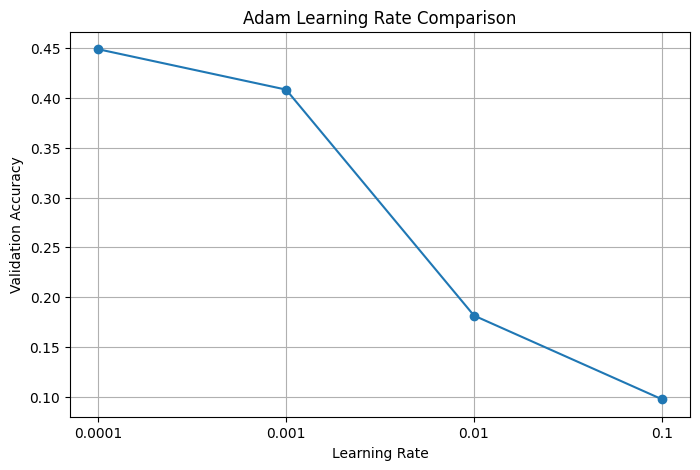

In [77]:
lrs = ["0.0001", "0.001", "0.01", "0.1"]
accs = [acc_0001, acc_001, acc_01, acc_1]

plt.figure(figsize=(8, 5))
plt.plot(lrs, accs, marker="o")
plt.xlabel("Learning Rate")
plt.ylabel("Validation Accuracy")
plt.title("Adam Learning Rate Comparison")
plt.grid(True)
plt.show()

```text
Adam Optimizer의 Learning Rate를 0.0001, 0.001, 0.01, 0.1로 변경하며 실험하였다.

실험 결과 0.0001에서 가장 높은 Validation Accuracy(44.91%)를 기록하였다.

반면 Learning Rate가 증가할수록 성능이 급격히 감소하였으며,
0.1에서는 약 9.7%로 랜덤 추측 수준의 정확도를 보였다.

이는 Learning Rate가 너무 크면 가중치가 최적점을 지나치면서
안정적으로 수렴하지 못하기 때문이다.

따라서 Learning Rate는 모델 성능에 큰 영향을 주는 중요한 하이퍼파라미터이며,
문제와 모델 구조에 따라 적절한 값을 선택해야 함을 확인하였다.
```